# Guided Onboarding: Member Activation and Retention

## tl;dr

- Guided onboarding increased 7-day activation from **31.9% to 40.8%**:
  **+8.9 percentage points**, 95% CI **[+6.5, +11.3]**.
- D60 subscription retention increased from **61.9% to 62.8%**, but the
  **+0.9-point** estimate is inconclusive: 95% CI **[-1.5, +3.4]**.
- D60 engaged retention increased **+3.4 points**, while 24-hour pairing and
  14-day cancellation showed no detected material harm.
- **Recommendation:** stage the rollout and retain a control holdout. The
  activation evidence is strong; the long-term subscription outcome still
  needs monitoring.

> PulsePath and every record in this notebook are synthetic. This is a
> portfolio case study, not an analysis of WHOOP or any real member.

## Context & Methods

The product decision is whether to roll out guided onboarding to new wearable
members. The primary KPI is 7-day activation; D60 subscription retention is the
longer-term outcome. The analysis uses intention-to-treat, so every assigned
member remains in the denominator.

### Key Assumptions

- A valid wear day has at least 18 hours of simulated wear.
- Activation requires five valid wear days, completed calibration, and three
  insight views during relative days 0–6.
- D60 engaged retention requires an active subscription on day 60 and at least
  three valid wear days during days 54–60.
- Segment results are exploratory because the experiment was designed for the
  overall effect.

In [1]:
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

ROOT = Path.cwd()
DATABASE_PATH = ROOT / "data" / "processed" / "pulsepath.duckdb"
connection = duckdb.connect(str(DATABASE_PATH), read_only=True)
plt.style.use("seaborn-v0_8-whitegrid")

## Data

### 1. Load reviewed member outcomes

In [2]:
outcomes = connection.sql("""
    select *
    from member_outcomes
    order by member_id
""").df()

print(f"Members: {len(outcomes):,}")
print(f"Unique member IDs: {outcomes['member_id'].nunique():,}")
print(f"Signup range: {outcomes['signup_date'].min()} to {outcomes['signup_date'].max()}")
outcomes.head()

Members: 6,000
Unique member IDs: 6,000
Signup range: 2026-01-01 00:00:00 to 2026-03-31 00:00:00


,member_id,signup_date,acquisition_channel,plan_tier,platform,age_band,experiment_name,experiment_variant,assignment_date,device_paired_24h,...,valid_wear_days_7d,insight_views_7d,sleep_days_7d,coaching_days_7d,activated_7d,retained_60d,valid_wear_days_54_60,insight_views_54_60,engaged_retained_60d,cancelled_14d
0,M000001,2026-03-23,Referral,Core,iOS,25–34,guided_onboarding_v1,Control,2026-03-23,True,...,5,3.0,5,0,True,True,2,1.0,False,False
1,M000002,2026-03-30,Organic,Health+,iOS,25–34,guided_onboarding_v1,Control,2026-03-30,True,...,4,6.0,3,3,False,False,2,1.0,False,False
2,M000003,2026-02-11,Organic,Performance,Android,25–34,guided_onboarding_v1,Control,2026-02-11,False,...,1,1.0,1,0,False,False,0,0.0,False,False
3,M000004,2026-03-25,Partnerships,Performance,Android,25–34,guided_onboarding_v1,Control,2026-03-25,False,...,4,4.0,4,1,False,False,0,0.0,False,False
4,M000005,2026-01-09,Organic,Core,Android,25–34,guided_onboarding_v1,Guided onboarding,2026-01-09,True,...,3,1.0,2,0,False,True,2,0.0,False,False


### 2. Check assignment, completeness, and analytical grain

In [3]:
quality_summary = pd.DataFrame({
    "check": [
        "Duplicate member IDs",
        "Missing experiment variant",
        "Missing activation outcome",
        "Missing D60 retention outcome",
        "Wear days outside 0–7",
    ],
    "failures": [
        outcomes.duplicated("member_id").sum(),
        outcomes["experiment_variant"].isna().sum(),
        outcomes["activated_7d"].isna().sum(),
        outcomes["retained_60d"].isna().sum(),
        (~outcomes["valid_wear_days_7d"].between(0, 7)).sum(),
    ],
})

assignment = outcomes["experiment_variant"].value_counts().rename_axis("variant").reset_index(name="members")
display(quality_summary)
display(assignment)

,check,failures
0,Duplicate member IDs,0
1,Missing experiment variant,0
2,Missing activation outcome,0
3,Missing D60 retention outcome,0
4,Wear days outside 0–7,0


,variant,members
0,Control,3013
1,Guided onboarding,2987


## Results

### 3. Recalculate experiment lift and uncertainty

The comparison below is independent of the dashboard export and uses the
member-level outcome table.

In [4]:
def difference_in_proportions(frame, outcome):
    treatment = frame.loc[
        frame["experiment_variant"].eq("Guided onboarding"), outcome
    ].astype(int)
    control = frame.loc[frame["experiment_variant"].eq("Control"), outcome].astype(int)
    treatment_rate = treatment.mean()
    control_rate = control.mean()
    lift = treatment_rate - control_rate
    standard_error = np.sqrt(
        treatment_rate * (1 - treatment_rate) / len(treatment)
        + control_rate * (1 - control_rate) / len(control)
    )
    z_value = norm.ppf(0.975)
    z_score = lift / standard_error
    return {
        "control_rate": control_rate,
        "guided_rate": treatment_rate,
        "absolute_lift": lift,
        "ci_low": lift - z_value * standard_error,
        "ci_high": lift + z_value * standard_error,
        "p_value": 2 * (1 - norm.cdf(abs(z_score))),
    }

metric_map = {
    "7-day activation": "activated_7d",
    "D60 subscription retention": "retained_60d",
    "D60 engaged retention": "engaged_retained_60d",
    "24-hour device pairing": "device_paired_24h",
    "14-day cancellation": "cancelled_14d",
}
results = pd.DataFrame([
    {"metric": label, **difference_in_proportions(outcomes, column)}
    for label, column in metric_map.items()
])
results.style.format({
    "control_rate": "{:.1%}",
    "guided_rate": "{:.1%}",
    "absolute_lift": "{:+.1%}",
    "ci_low": "{:+.1%}",
    "ci_high": "{:+.1%}",
    "p_value": "{:.4f}",
})

,metric,control_rate,guided_rate,absolute_lift,ci_low,ci_high,p_value
0,7-day activation,31.9%,40.8%,+8.9%,+6.5%,+11.3%,0.0000
1,D60 subscription retention,61.9%,62.8%,+0.9%,-1.5%,+3.4%,0.4521
2,D60 engaged retention,49.4%,52.7%,+3.4%,+0.8%,+5.9%,0.0089
3,24-hour device pairing,92.8%,92.1%,-0.8%,-2.1%,+0.6%,0.2619
4,14-day cancellation,4.9%,4.8%,-0.1%,-1.2%,+1.0%,0.8232


### 4. Compare the primary outcome and long-term guardrails

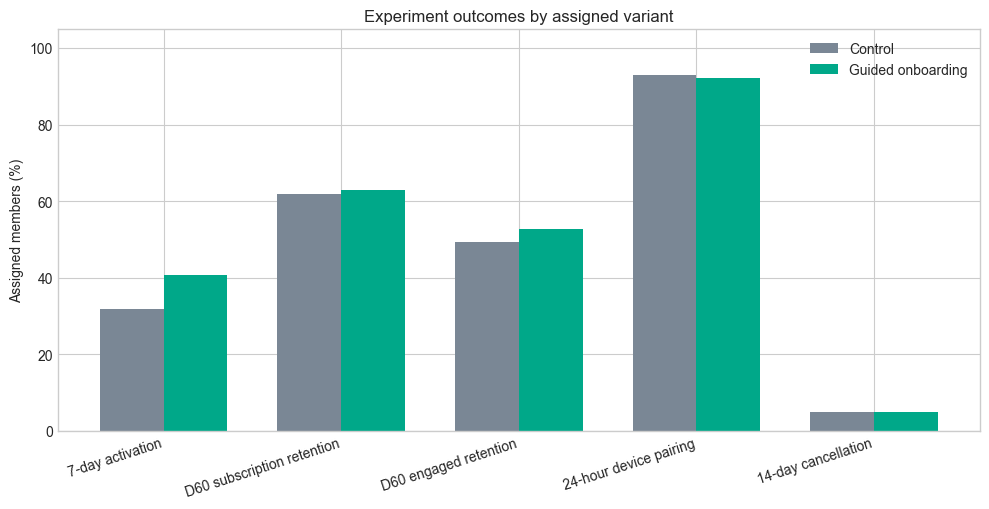

In [5]:
plot_metrics = results.iloc[:5].copy()
plot_metrics["control_pct"] = plot_metrics["control_rate"] * 100
plot_metrics["guided_pct"] = plot_metrics["guided_rate"] * 100

positions = np.arange(len(plot_metrics))
width = 0.36
fig, ax = plt.subplots(figsize=(10, 5.2))
ax.bar(positions - width / 2, plot_metrics["control_pct"], width, label="Control", color="#7a8795")
ax.bar(positions + width / 2, plot_metrics["guided_pct"], width, label="Guided onboarding", color="#00a889")
ax.set_ylabel("Assigned members (%)")
ax.set_xticks(positions)
ax.set_xticklabels(plot_metrics["metric"], rotation=18, ha="right")
ax.set_title("Experiment outcomes by assigned variant")
ax.legend(frameon=False)
ax.set_ylim(0, max(plot_metrics["guided_pct"].max(), plot_metrics["control_pct"].max()) + 12)
plt.tight_layout()
plt.show()

The activation movement is large and precisely estimated. D60 subscription
retention is directionally positive, but its interval crosses zero and the
pre-agreed one-point non-inferiority boundary. Engaged retention provides a
useful secondary signal, not a substitute for the subscription outcome.

### 5. Inspect which activation components moved

In [6]:
drivers = connection.sql("""
    select
        experiment_variant,
        avg(device_paired_24h::integer) as paired_24h,
        avg(calibration_completed_7d::integer) as calibrated_7d,
        avg((valid_wear_days_7d >= 5)::integer) as consistent_wear_7d,
        avg((insight_views_7d >= 3)::integer) as insight_threshold_7d,
        avg(activated_7d::integer) as activated_7d
    from member_outcomes
    group by 1
    order by 1
""").df()
drivers.style.format({
    "paired_24h": "{:.1%}",
    "calibrated_7d": "{:.1%}",
    "consistent_wear_7d": "{:.1%}",
    "insight_threshold_7d": "{:.1%}",
    "activated_7d": "{:.1%}",
})

,experiment_variant,paired_24h,calibrated_7d,consistent_wear_7d,insight_threshold_7d,activated_7d
0,Control,92.8%,73.2%,67.0%,52.8%,31.9%
1,Guided onboarding,92.1%,78.0%,74.1%,60.5%,40.8%


Pairing did not improve, so the experiment's value appears after initial
hardware setup. That suggests the next iteration should preserve guided
calibration and insight education while separately addressing pairing friction.

### 6. Review pre-treatment segments without overclaiming

In [7]:
segments = connection.sql("""
    select
        segment_type,
        segment_value,
        max(activation_rate) filter (
            where experiment_variant = 'Guided onboarding'
        ) - max(activation_rate) filter (
            where experiment_variant = 'Control'
        ) as activation_lift,
        max(retained_60d_rate) filter (
            where experiment_variant = 'Guided onboarding'
        ) - max(retained_60d_rate) filter (
            where experiment_variant = 'Control'
        ) as retention_lift,
        min(assigned_members) as minimum_variant_n
    from experiment_results
    where segment_type <> 'Overall'
    group by 1, 2
    order by 1, activation_lift desc
""").df()
segments.style.format({
    "activation_lift": "{:+.1%}",
    "retention_lift": "{:+.1%}",
    "minimum_variant_n": "{:,.0f}",
})

,segment_type,segment_value,activation_lift,retention_lift,minimum_variant_n
0,Acquisition channel,Partnerships,+13.5%,+6.9%,443
1,Acquisition channel,Paid Social,+10.0%,+2.8%,873
2,Acquisition channel,Organic,+8.2%,-1.5%,989
3,Acquisition channel,Referral,+5.5%,-1.8%,653
4,Plan tier,Core,+10.9%,+1.6%,"1,263"
5,Plan tier,Health+,+8.3%,-2.6%,537
6,Plan tier,Performance,+7.1%,+1.8%,"1,164"
7,Platform,iOS,+9.2%,-0.3%,"1,791"
8,Platform,Android,+8.2%,+2.8%,"1,162"


Segment variation is useful for hypothesis generation, but none of these cuts
should determine targeting without multiplicity control and adequate power.

## Takeaways

1. **Stage the rollout rather than launching universally.** The activation
   improvement is clear, but the D60 subscription-retention estimate is not yet
   precise enough for an unconditional rollout.
2. **Preserve a randomized holdout.** Continue measuring D60 subscription and
   engaged retention until the lower interval clears the agreed
   non-inferiority margin.
3. **Keep the strongest experience components.** Guided calibration and early
   insight education moved; device pairing did not.
4. **Do not target from these subgroup cuts yet.** Segment differences are
   exploratory and may reflect sampling noise.

The complete validation report is saved in `validation/validation_report.md`.

In [8]:
connection.close()